# Line detection using Houghline method

In [2]:
import cv2
import numpy as np

# Read image
img = cv2.imread('image.png')

# Check if image loaded
if img is None:
    print("Image not found")
    exit()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

# Check if lines detected
if lines is not None:

    for r_theta in lines:
        r, theta = r_theta[0]

        a = np.cos(theta)
        b = np.sin(theta)

        x0 = a * r
        y0 = b * r

        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))

        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        cv2.line(img, (x1,y1), (x2,y2), (0,0,255), 2)

    cv2.imwrite('linesDetected.jpg', img)
    print("Lines detected and image saved")

else:
    print("No lines detected in image")

No lines detected in image


In [4]:
import cv2
import numpy as np

# Read image
image = cv2.imread('image.png')

# Convert image to grayscale
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

# Use canny edge detection
edges = cv2.Canny(gray,50,150,apertureSize=3)

# Apply HoughLinesP method to 
# to directly obtain line end points
lines_list =[]
lines = cv2.HoughLinesP(
            edges, # Input edge image
            1, # Distance resolution in pixels
            np.pi/180, # Angle resolution in radians
            threshold=100, # Min number of votes for valid line
            minLineLength=5, # Min allowed length of line
            maxLineGap=10 # Max allowed gap between line for joining them
            )

# Iterate over points
for points in lines:
      # Extracted points nested in the list
    x1,y1,x2,y2=points[0]
    # Draw the lines joing the points
    # On the original image
    cv2.line(image,(x1,y1),(x2,y2),(0,255,0),2)
    # Maintain a simples lookup list for points
    lines_list.append([(x1,y1),(x2,y2)])
    
# Save the result image
cv2.imwrite('detectedLines.png',image)

True

# Circle Detection

In [6]:
import cv2
import numpy as np

# Read image
img = cv2.imread("image.png")
output = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Reduce noise
gray = cv2.medianBlur(gray, 5)

# Detect circles
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,      
    param1=100,         
    param2=40,       
    minRadius=30,       
    maxRadius=60
)

# Draw only the first detected circle
if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0][0]
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Circle outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # Center point

# Show result
cv2.imshow('Detected Circle', output)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Detect corner of an image

In [7]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [9]:
img = cv2.imread('image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [10]:
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=27,
    qualityLevel=0.01,
    minDistance=10,
    blockSize=3,
    useHarrisDetector=False,
    k=0.04
)

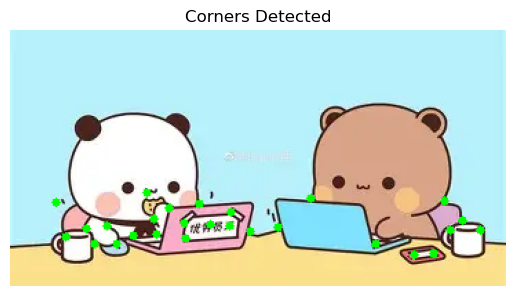

In [11]:
corners = np.intp(corners)  # Convert to integer coords
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(img, (x, y), radius=3, color=(0, 255, 0), thickness=-1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Corners Detected')
plt.axis('off')
plt.show()

# Corner Detection with Shi-Tomasi method

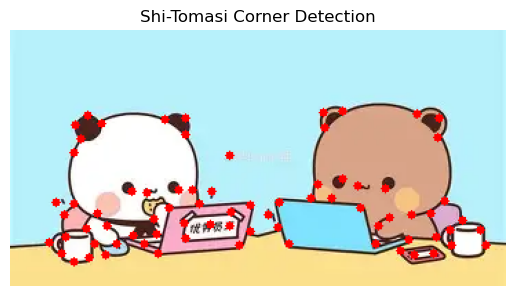

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.png')

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(gray_img, 100, 0.01, 10)
corners = np.int32(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(img, (x, y), 3, (0, 0, 255), -1)  

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Shi-Tomasi Corner Detection')
plt.axis('off')  
plt.show()

# Corner detection with Harris Corner Detection

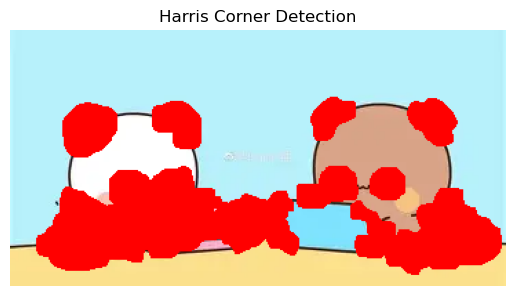

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "image.png"  
image = cv2.imread(image_path)

operatedImage = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
operatedImage = np.float32(operatedImage)


dest = cv2.cornerHarris(operatedImage, 17, 21, 0.01)
dest = cv2.dilate(dest, None)

image[dest > 0.01 * dest.max()] = [0, 0, 255]
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title('Harris Corner Detection')
plt.axis('off')  
plt.show()

# Find Circles and Ellipses in an Image

In [14]:
import cv2
import numpy as np

# Load image
image = cv2.imread('image.png', 0)

# Set our filtering parameters
# Initialize parameter setting using cv2.SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()

# Set Area filtering parameters
params.filterByArea = True
params.minArea = 100

# Set Circularity filtering parameters
params.filterByCircularity = True 
params.minCircularity = 0.9

# Set Convexity filtering parameters
params.filterByConvexity = True
params.minConvexity = 0.2
    
# Set inertia filtering parameters
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Create a detector with the parameters
detector = cv2.SimpleBlobDetector_create(params)
    
# Detect blobs
keypoints = detector.detect(image)

# Draw blobs on our image as red circles
blank = np.zeros((1, 1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0, 0, 255),
                          cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

number_of_blobs = len(keypoints)
text = "Number of Circular Blobs: " + str(len(keypoints))
cv2.putText(blobs, text, (20, 550),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 100, 255), 2)

# Show blobs
cv2.imshow("Filtering Circular Blobs Only", blobs)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Document field detection

In [19]:
import numpy as np
import cv2

field_threshold = {
    "prev_policy_no": 0.7,
    "address": 0.6,
}

# Function to generate bounding boxes
def getBoxed(img, img_gray, template, field_name="policy_no"):

    if template is None:
        print(field_name, " ")
        return img

    w, h = template.shape[::-1]

    # Template matching
    res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)

    hits = np.where(res >= field_threshold[field_name])

    for pt in zip(*hits[::-1]):
        cv2.rectangle(img, pt, (pt[0] + w, pt[1] + h), (0,255,255), 2)

        y = pt[1] - 10 if pt[1] - 10 > 10 else pt[1] + h + 20

        cv2.putText(img, field_name, (pt[0], y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 1)

    return img


# Main program

# Main document image
img = cv2.imread('image.png')

if img is None:
    print("image.png not found")
    exit()

# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Template images (cropped parts of the document)
template_add = cv2.imread('address.png', 0)
template_prev = cv2.imread('policy.png', 0)

# Detect fields
img = getBoxed(img.copy(), img_gray.copy(), template_add, 'address')
img = getBoxed(img.copy(), img_gray.copy(), template_prev, 'prev_policy_no')

# Show result
cv2.imshow("Detected Fields", img)

cv2.waitKey(0)
cv2.destroyAllWindows()

address  
prev_policy_no  


# Smile detection

In [3]:
import cv2

In [4]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_smile.xml')

In [5]:
cap = cv2.VideoCapture(0)

In [ ]:
while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Failed to grab frame.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]

        smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.8, minNeighbors=20, minSize=(25, 25))

        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(frame, (x + sx, y + sy), (x + sx + sw, y + sy + sh), (0, 255, 0), 2)

    cv2.imshow('Smile Detection', frame)

In [ ]:
if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

# Feature extraction and image classification using OpenCV

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
image = cv2.imread('image.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

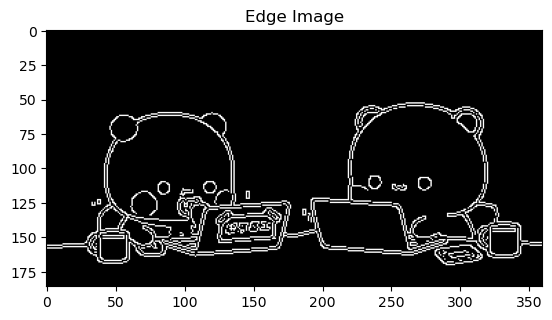

In [5]:
edges = cv2.Canny(gray_image, 100, 200)
plt.imshow(edges, cmap='gray')
plt.title('Edge Image')
plt.show()

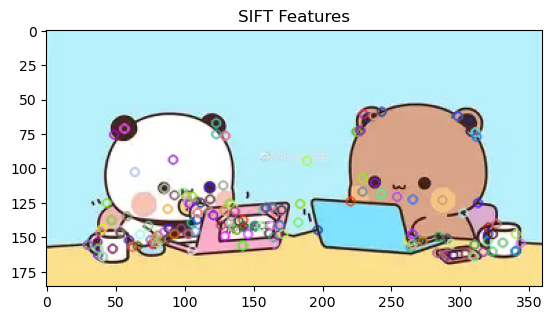

In [6]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)
plt.imshow(cv2.cvtColor(image_with_sift, cv2.COLOR_BGR2RGB))
plt.title('SIFT Features')
plt.show()

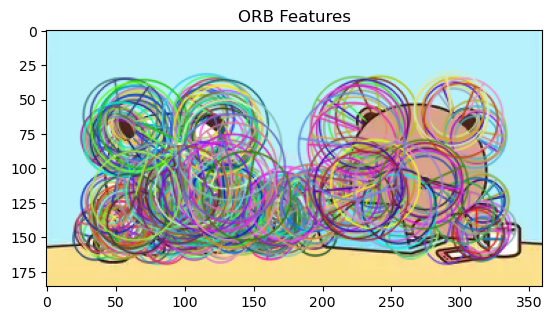

In [7]:
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray_image, None)
image_with_orb = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_with_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB Features')
plt.show()

In [8]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

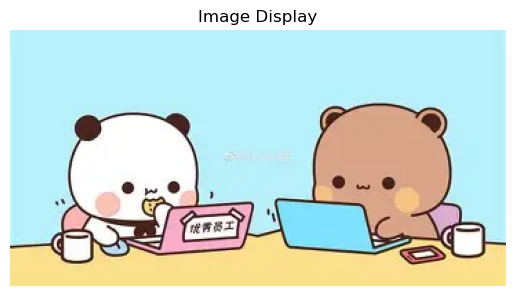

In [14]:
import cv2
from matplotlib import pyplot as plt

# Correct file path (use raw string r'' or forward slashes)
img = cv2.imread(r'image.png')  # or 'images/image.png'

# Convert BGR to RGB for correct colors in matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.title("Image Display")
plt.show()

In [15]:
#Converting the image to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape
plt.imshow(gray)

In [16]:
plt.imshow(gray, cmap='gray')

In [28]:
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    print("First face coordinates:", x, y, w, h)
else:
    print("No faces detected in the image")

No faces detected in the image


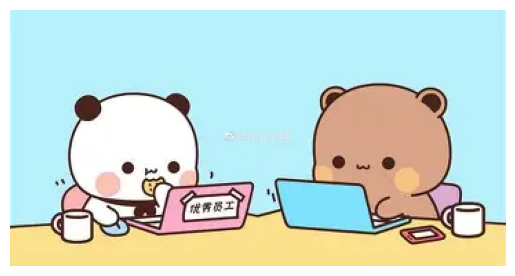

In [29]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
if len(faces) > 0: x, y, w, h = faces[0]; img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

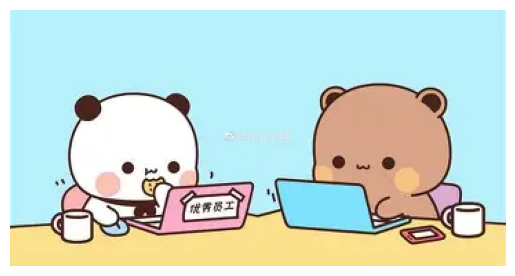

In [31]:
import cv2
from matplotlib import pyplot as plt

# Load image and convert to grayscale
img = cv2.imread('image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

# Display the result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [33]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H